# Classification d'images — Multi-label CNN

## Description du projet

Ce notebook développe des modèles de **classification multi-label d'images** sur le dataset Kaggle (Multi-label Classification Competition 2023).  
Chaque image peut être associée à **plusieurs labels** parmi 18 classes (1–19, sauf 12).

**Stratégie expérimentale :**
1. Baseline CNN simple
2. Transfer learning — EfficientNetB0 (feature extractor)
3. Fine-tuning partiel — EfficientNetB0

**Métriques :** F1 micro, F1 macro, précision, rappel (adaptées au multi-label)

---

**Structure :**
1. Configuration et chargement des données
2. Prétraitement des images
3. Protocole d'évaluation
4. Modèle 1 — Baseline CNN
5. Modèle 2 — Transfer Learning EfficientNetB0
6. Modèle 3 — Fine-tuning partiel
7. Comparaison et choix du modèle final
8. Analyse du modèle final (LIME, erreurs)

## 1. Configuration et chargement des données

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, multilabel_confusion_matrix
)
import pickle

plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

# ── Chemins ──────────────────────────────────────────────────────────────────
# Structure du dataset extrait :
#   data/multimodal/COMP5329S1A2Dataset/data/*.jpg   → images (0.jpg, 1.jpg, ...)
#   data/multimodal/COMP5329S1A2Dataset/train.csv    → annotations
DATASET_DIR = '../data/multimodal/COMP5329S1A2Dataset/'
DATA_DIR    = '../data/multimodal/'                  # dossier pour les artefacts générés
IMG_DIR     = os.path.join(DATASET_DIR, 'data/')    # images/*.jpg
TRAIN_CSV   = os.path.join(DATASET_DIR, 'train.csv')

# Hyperparamètres
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 1e-3
THRESHOLD  = 0.5   # seuil de décision sigmoid
N_CLASSES  = 18    # labels 1–19 sauf 12
ALL_LABELS = [l for l in range(1, 20) if l != 12]

print("Répertoire images  :", os.path.abspath(IMG_DIR))
print("train.csv existe   :", os.path.exists(TRAIN_CSV))


Device : cpu
Répertoire images  : c:\Users\DELL\Desktop\ESTIA\COURS\MLOps\Projet_final\data\multimodal\COMP5329S1A2Dataset\data
train.csv existe   : True


In [2]:
# ── Chargement et split (mêmes index que EDA) ─────────────────────────────────
# on_bad_lines='skip' : certaines captions contiennent des virgules → lignes mal formées
df = pd.read_csv(TRAIN_CSV, on_bad_lines='skip')

def parse_labels(s):
    return [int(x) for x in str(s).split()] if pd.notna(s) else []

df['labels_list'] = df['Labels'].apply(parse_labels)

# Charger les index sauvegardés dans le notebook EDA
idx_train = pd.read_csv('../data/multimodal/idx_train.csv', header=None)[0].tolist()
idx_val   = pd.read_csv('../data/multimodal/idx_val.csv',   header=None)[0].tolist()
idx_test  = pd.read_csv('../data/multimodal/idx_test.csv',  header=None)[0].tolist()

df_train = df.loc[idx_train].reset_index(drop=True)
df_val   = df.loc[idx_val].reset_index(drop=True)
df_test  = df.loc[idx_test].reset_index(drop=True)

# Binarisation des labels
mlb = MultiLabelBinarizer(classes=ALL_LABELS)
y_train = mlb.fit_transform(df_train['labels_list']).astype(np.float32)
y_val   = mlb.transform(df_val['labels_list']).astype(np.float32)
y_test  = mlb.transform(df_test['labels_list']).astype(np.float32)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
print(f"y_train shape: {y_train.shape}")


Train: 20997 | Val: 4499 | Test: 4500
y_train shape: (20997, 18)


## 2. Prétraitement des images

In [3]:
# ── Dataset PyTorch ───────────────────────────────────────────────────────────
class MultiLabelImageDataset(Dataset):
    """Dataset multi-label pour la classification d'images."""
    def __init__(self, df, labels, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.labels    = labels
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.df.iloc[idx]['ImageID'])
        image    = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, label


# ── Transformations ────────────────────────────────────────────────────────────
# Entraînement : data augmentation pour régularisation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # Normalisation ImageNet
                         std=[0.229, 0.224, 0.225]),
])

# Validation/Test : pas d'augmentation
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Datasets et DataLoaders
train_dataset = MultiLabelImageDataset(df_train, y_train, IMG_DIR, train_transform)
val_dataset   = MultiLabelImageDataset(df_val,   y_val,   IMG_DIR, val_transform)
test_dataset  = MultiLabelImageDataset(df_test,  y_test,  IMG_DIR, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Batches par epoch — Train: {len(train_loader)} | Val: {len(val_loader)}")

Batches par epoch — Train: 657 | Val: 141


## 3. Protocole d'évaluation

In [4]:
# ── Fonctions d'évaluation ────────────────────────────────────────────────────

def evaluate_model(model, loader, device, threshold=0.5):
    """Évalue le modèle sur un DataLoader, retourne les prédictions et labels."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            probs  = torch.sigmoid(logits).cpu().numpy()
            all_preds.append(probs)
            all_labels.append(labels.numpy())
    y_pred_proba = np.vstack(all_preds)
    y_true       = np.vstack(all_labels)
    y_pred       = (y_pred_proba >= threshold).astype(int)
    return y_true, y_pred, y_pred_proba


def print_metrics(y_true, y_pred, name=''):
    """Affiche F1 micro, F1 macro, précision et rappel."""
    f1_micro = f1_score(y_true, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    prec     = precision_score(y_true, y_pred, average='micro', zero_division=0)
    rec      = recall_score(y_true, y_pred, average='micro', zero_division=0)
    print(f"{'='*40}")
    print(f"  {name}")
    print(f"  F1 micro : {f1_micro:.4f}")
    print(f"  F1 macro : {f1_macro:.4f}")
    print(f"  Précision: {prec:.4f}")
    print(f"  Rappel   : {rec:.4f}")
    print(f"{'='*40}")
    return {'f1_micro': f1_micro, 'f1_macro': f1_macro, 'precision': prec, 'recall': rec}


def plot_training_curves(history, title):
    """Affiche les courbes de loss et F1 en entraînement/validation."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history['train_loss'], label='Train loss')
    axes[0].plot(history['val_loss'],   label='Val loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('BCELoss')
    axes[0].legend()

    axes[1].plot(history['train_f1'], label='Train F1 micro')
    axes[1].plot(history['val_f1'],   label='Val F1 micro')
    axes[1].set_title(f'{title} — F1 micro')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1 micro')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'../monitoring/output/img_{title.replace(" ", "_")}_curves.png', bbox_inches='tight')
    plt.show()


def train_model(model, train_loader, val_loader, epochs, lr, device, model_name):
    """Boucle d'entraînement avec early stopping sur val_loss."""
    # Pondération pour déséquilibre : pos_weight = n_neg / n_pos
    pos = y_train.sum(axis=0)
    neg = len(y_train) - pos
    pos_weight = torch.tensor(neg / (pos + 1e-6), dtype=torch.float32).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_f1  = 0
    patience_cnt = 0
    PATIENCE     = 5

    for epoch in range(epochs):
        # ── Entraînement ──────────────────────────────────────────────────────
        model.train()
        train_losses, train_preds, train_labels = [], [], []
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            train_preds.append(torch.sigmoid(logits).detach().cpu().numpy())
            train_labels.append(labels.detach().cpu().numpy())

        # ── Validation ────────────────────────────────────────────────────────
        model.eval()
        val_losses, val_preds, val_labels_list = [], [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                logits = model(images)
                loss   = criterion(logits, labels)
                val_losses.append(loss.item())
                val_preds.append(torch.sigmoid(logits).cpu().numpy())
                val_labels_list.append(labels.cpu().numpy())

        # Calcul métriques
        yt_tr = np.vstack(train_labels)
        yp_tr = (np.vstack(train_preds) >= THRESHOLD).astype(int)
        yt_v  = np.vstack(val_labels_list)
        yp_v  = (np.vstack(val_preds) >= THRESHOLD).astype(int)

        t_loss = np.mean(train_losses)
        v_loss = np.mean(val_losses)
        t_f1   = f1_score(yt_tr, yp_tr, average='micro', zero_division=0)
        v_f1   = f1_score(yt_v,  yp_v,  average='micro', zero_division=0)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_f1'].append(t_f1)
        history['val_f1'].append(v_f1)

        scheduler.step(v_loss)

        print(f"Epoch {epoch+1:3d}/{epochs} | "
              f"train_loss={t_loss:.4f} val_loss={v_loss:.4f} | "
              f"train_F1={t_f1:.4f} val_F1={v_f1:.4f}")

        # Early stopping
        if v_f1 > best_val_f1:
            best_val_f1 = v_f1
            torch.save(model.state_dict(), f'../model/{model_name}_best.pth')
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"  → Early stopping à l'epoch {epoch+1}")
                break

    # Recharger les meilleurs poids
    model.load_state_dict(torch.load(f'../model/{model_name}_best.pth', map_location=device))
    return history

## 4. Modèle 1 — Baseline CNN

In [5]:
class BaselineCNN(nn.Module):
    """
    CNN simple de référence (baseline).
    Architecture : 3 blocs Conv-BN-ReLU-Pool → Flatten → Dense → Sigmoid
    Choix architecturaux :
      - Batch Normalization pour stabiliser l'entraînement
      - Dropout pour la régularisation
      - Sortie linéaire (BCEWithLogitsLoss gère le sigmoid)
    """
    def __init__(self, n_classes=18):
        super().__init__()
        self.features = nn.Sequential(
            # Bloc 1 : 3→32 canaux, 224→112
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Bloc 2 : 32→64 canaux, 112→56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Bloc 3 : 64→128 canaux, 56→28
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),   # 128×4×4 = 2048
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes),      # sortie linéaire (logits)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


baseline_cnn = BaselineCNN(n_classes=N_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in baseline_cnn.parameters())
print(f"Baseline CNN — Paramètres : {total_params:,}")

Baseline CNN — Paramètres : 622,866


In [6]:
# Entraînement du baseline
print("=== Entraînement Baseline CNN ===")
hist_baseline = train_model(
    baseline_cnn, train_loader, val_loader,
    epochs=EPOCHS, lr=LR, device=DEVICE, model_name='baseline_cnn'
)

=== Entraînement Baseline CNN ===
Epoch   1/20 | train_loss=1.2043 val_loss=1.1335 | train_F1=0.1942 val_F1=0.2546
Epoch   2/20 | train_loss=1.1623 val_loss=1.1125 | train_F1=0.2101 val_F1=0.2707
Epoch   3/20 | train_loss=1.1440 val_loss=1.1202 | train_F1=0.2192 val_F1=0.2321
Epoch   4/20 | train_loss=1.1353 val_loss=1.0900 | train_F1=0.2254 val_F1=0.2175
Epoch   5/20 | train_loss=1.1270 val_loss=1.0843 | train_F1=0.2241 val_F1=0.2605
Epoch   6/20 | train_loss=1.1102 val_loss=1.0730 | train_F1=0.2327 val_F1=0.2555
Epoch   7/20 | train_loss=1.1127 val_loss=1.0606 | train_F1=0.2357 val_F1=0.2822
Epoch   8/20 | train_loss=1.1098 val_loss=1.0692 | train_F1=0.2300 val_F1=0.2751
Epoch   9/20 | train_loss=1.1012 val_loss=1.0648 | train_F1=0.2302 val_F1=0.2565
Epoch  10/20 | train_loss=1.0945 val_loss=1.0576 | train_F1=0.2357 val_F1=0.2736
Epoch  11/20 | train_loss=1.0926 val_loss=1.0593 | train_F1=0.2353 val_F1=0.2790
Epoch  12/20 | train_loss=1.0897 val_loss=1.0561 | train_F1=0.2366 val_F1=0

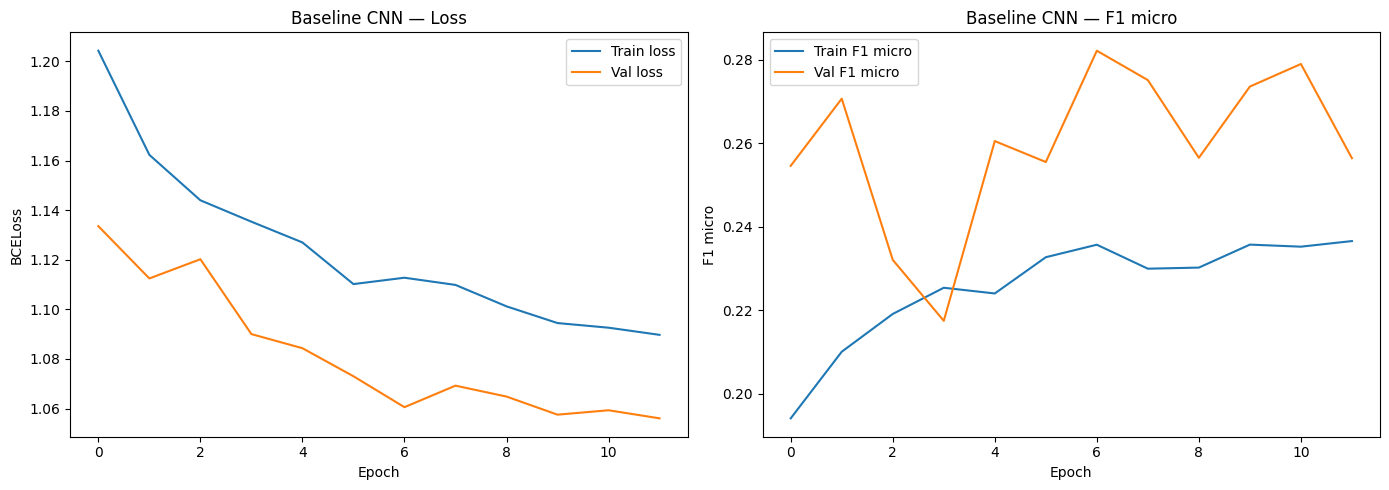

  Baseline CNN — Test
  F1 micro : 0.2873
  F1 macro : 0.2072
  Précision: 0.1770
  Rappel   : 0.7621


In [7]:
plot_training_curves(hist_baseline, 'Baseline CNN')

# Évaluation sur le test
y_true_b, y_pred_b, _ = evaluate_model(baseline_cnn, test_loader, DEVICE)
metrics_baseline = print_metrics(y_true_b, y_pred_b, 'Baseline CNN — Test')

## 5. Modèle 2 — Transfer Learning EfficientNetB0 (feature extractor)

In [8]:
# ── EfficientNetB0 — Feature extractor (toutes couches gelées) ────────────────
# Justification : EfficientNet est pré-entraîné sur ImageNet (1.2M images, 1000 classes)
# → les features apprises sont générales et riches.
# En gelant les couches, on évite le surapprentissage sur notre dataset limité.

efficientnet_fe = models.efficientnet_b0(weights='IMAGENET1K_V1')

# Geler toutes les couches (feature extractor)
for param in efficientnet_fe.parameters():
    param.requires_grad = False

# Remplacer la tête de classification
in_features = efficientnet_fe.classifier[1].in_features
efficientnet_fe.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, N_CLASSES),
)
efficientnet_fe = efficientnet_fe.to(DEVICE)

trainable = sum(p.numel() for p in efficientnet_fe.parameters() if p.requires_grad)
total     = sum(p.numel() for p in efficientnet_fe.parameters())
print(f"EfficientNetB0 FE — Paramètres entraînables : {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\DELL/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:15<00:00, 1.35MB/s]

EfficientNetB0 FE — Paramètres entraînables : 23,058 / 4,030,606


=== Entraînement EfficientNetB0 Feature Extractor ===
Epoch   1/20 | train_loss=0.9039 val_loss=0.7576 | train_F1=0.3678 val_F1=0.4053
Epoch   2/20 | train_loss=0.7789 val_loss=0.7299 | train_F1=0.3959 val_F1=0.4053
Epoch   3/20 | train_loss=0.7547 val_loss=0.7185 | train_F1=0.4056 val_F1=0.3995
Epoch   4/20 | train_loss=0.7490 val_loss=0.7051 | train_F1=0.4080 val_F1=0.4105
Epoch   5/20 | train_loss=0.7445 val_loss=0.7095 | train_F1=0.4078 val_F1=0.4290
Epoch   6/20 | train_loss=0.7307 val_loss=0.7020 | train_F1=0.4160 val_F1=0.4307
Epoch   7/20 | train_loss=0.7270 val_loss=0.7027 | train_F1=0.4168 val_F1=0.4423
Epoch   8/20 | train_loss=0.7230 val_loss=0.7040 | train_F1=0.4207 val_F1=0.4550
Epoch   9/20 | train_loss=0.7188 val_loss=0.7034 | train_F1=0.4216 val_F1=0.4474
Epoch  10/20 | train_loss=0.7199 val_loss=0.6953 | train_F1=0.4219 val_F1=0.4579
Epoch  11/20 | train_loss=0.7189 val_loss=0.6953 | train_F1=0.4211 val_F1=0.4403
Epoch  12/20 | train_loss=0.7181 val_loss=0.6904 | trai

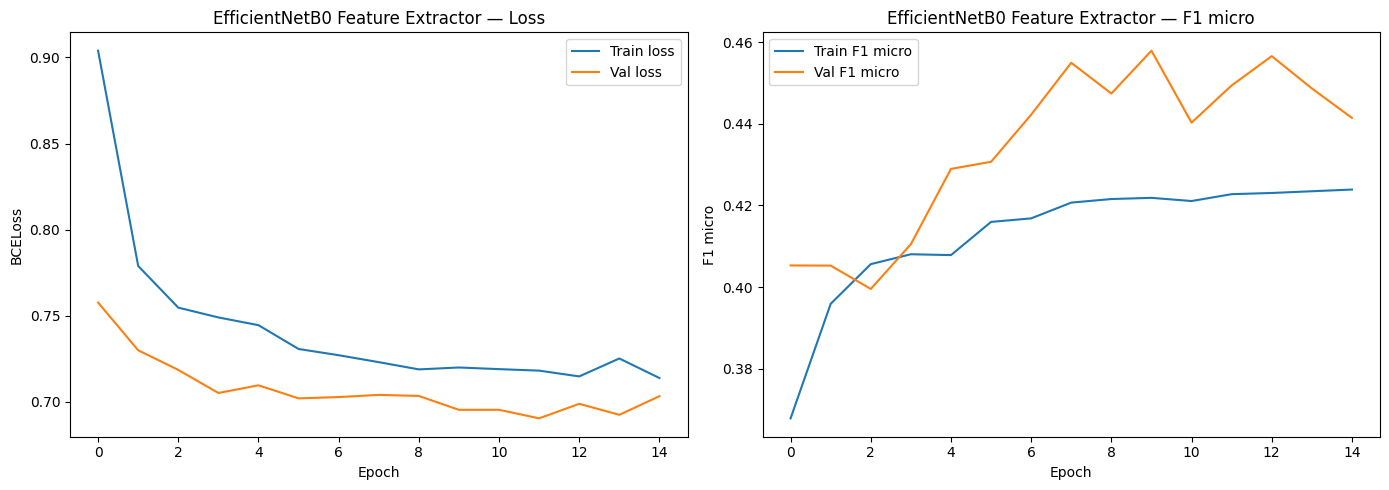

  EfficientNetB0 FE — Test
  F1 micro : 0.4544
  F1 macro : 0.3484
  Précision: 0.3177
  Rappel   : 0.7974


In [9]:
print("=== Entraînement EfficientNetB0 Feature Extractor ===")
hist_fe = train_model(
    efficientnet_fe, train_loader, val_loader,
    epochs=EPOCHS, lr=LR, device=DEVICE, model_name='efficientnet_fe'
)

plot_training_curves(hist_fe, 'EfficientNetB0 Feature Extractor')
y_true_fe, y_pred_fe, _ = evaluate_model(efficientnet_fe, test_loader, DEVICE)
metrics_fe = print_metrics(y_true_fe, y_pred_fe, 'EfficientNetB0 FE — Test')

## 6. Modèle 3 — Fine-tuning partiel EfficientNetB0

In [10]:
# ── EfficientNetB0 — Fine-tuning des 3 derniers blocs ─────────────────────────
# Justification : on libère les dernières couches du backbone pour adapter
# les représentations à notre domaine spécifique. LR plus faible pour les
# couches pré-entraînées (éviter de détruire les features ImageNet).

efficientnet_ft = models.efficientnet_b0(weights='IMAGENET1K_V1')

# Geler d'abord tout
for param in efficientnet_ft.parameters():
    param.requires_grad = False

# Dégeler les 3 derniers blocs features + classifier
blocks_to_unfreeze = list(efficientnet_ft.features.children())[-3:]
for block in blocks_to_unfreeze:
    for param in block.parameters():
        param.requires_grad = True

# Nouvelle tête
in_features = efficientnet_ft.classifier[1].in_features
efficientnet_ft.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, N_CLASSES),
)
efficientnet_ft = efficientnet_ft.to(DEVICE)

trainable = sum(p.numel() for p in efficientnet_ft.parameters() if p.requires_grad)
total     = sum(p.numel() for p in efficientnet_ft.parameters())
print(f"EfficientNetB0 FT — Paramètres entraînables : {trainable:,} / {total:,}")

EfficientNetB0 FT — Paramètres entraînables : 3,178,798 / 4,030,606


=== Entraînement EfficientNetB0 Fine-tuning ===
Epoch   1/20 | train_loss=0.8482 val_loss=0.6098 | train_F1=0.3641 val_F1=0.4700
Epoch   2/20 | train_loss=0.6048 val_loss=0.5493 | train_F1=0.4791 val_F1=0.5318
Epoch   3/20 | train_loss=0.5270 val_loss=0.5438 | train_F1=0.5218 val_F1=0.5389
Epoch   4/20 | train_loss=0.4732 val_loss=0.5430 | train_F1=0.5469 val_F1=0.5580
Epoch   5/20 | train_loss=0.4463 val_loss=0.5754 | train_F1=0.5666 val_F1=0.5954
Epoch   6/20 | train_loss=0.4087 val_loss=0.5665 | train_F1=0.5894 val_F1=0.5653
Epoch   7/20 | train_loss=0.3730 val_loss=0.6119 | train_F1=0.6084 val_F1=0.5996
Epoch   8/20 | train_loss=0.3563 val_loss=0.6531 | train_F1=0.6208 val_F1=0.6324
Epoch   9/20 | train_loss=0.3197 val_loss=0.6465 | train_F1=0.6465 val_F1=0.6105
Epoch  10/20 | train_loss=0.3061 val_loss=0.6709 | train_F1=0.6555 val_F1=0.6333
Epoch  11/20 | train_loss=0.2940 val_loss=0.6986 | train_F1=0.6629 val_F1=0.6243
Epoch  12/20 | train_loss=0.2834 val_loss=0.7061 | train_F1=0

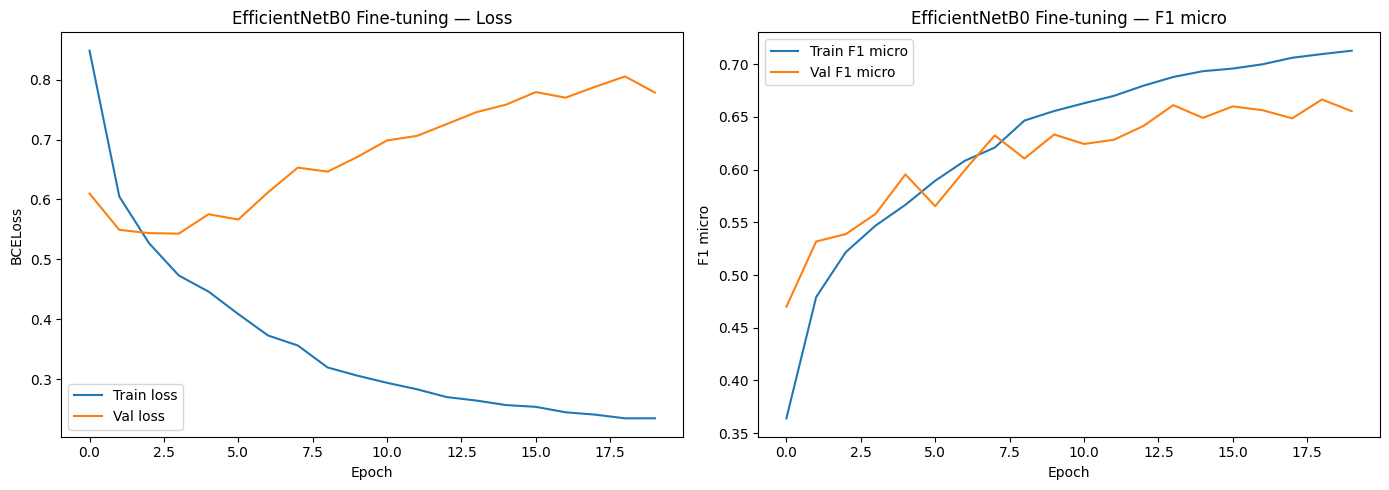

  EfficientNetB0 FT — Test
  F1 micro : 0.6665
  F1 macro : 0.5553
  Précision: 0.5748
  Rappel   : 0.7930


In [11]:
# Fine-tuning avec un LR plus faible pour les couches dégeleées
print("=== Entraînement EfficientNetB0 Fine-tuning ===")
hist_ft = train_model(
    efficientnet_ft, train_loader, val_loader,
    epochs=EPOCHS, lr=1e-4, device=DEVICE, model_name='efficientnet_ft'
)

plot_training_curves(hist_ft, 'EfficientNetB0 Fine-tuning')
y_true_ft, y_pred_ft, _ = evaluate_model(efficientnet_ft, test_loader, DEVICE)
metrics_ft = print_metrics(y_true_ft, y_pred_ft, 'EfficientNetB0 FT — Test')

## 7. Comparaison et choix du modèle final

In [12]:
# ── Tableau comparatif ────────────────────────────────────────────────────────
comparison = pd.DataFrame([
    {'Modèle': 'Baseline CNN',               **metrics_baseline},
    {'Modèle': 'EfficientNetB0 Feature Extractor', **metrics_fe},
    {'Modèle': 'EfficientNetB0 Fine-tuning', **metrics_ft},
])
print(comparison.to_string(index=False, float_format='{:.4f}'.format))

                          Modèle  f1_micro  f1_macro  precision  recall
                    Baseline CNN    0.2873    0.2072     0.1770  0.7621
EfficientNetB0 Feature Extractor    0.4544    0.3484     0.3177  0.7974
      EfficientNetB0 Fine-tuning    0.6665    0.5553     0.5748  0.7930


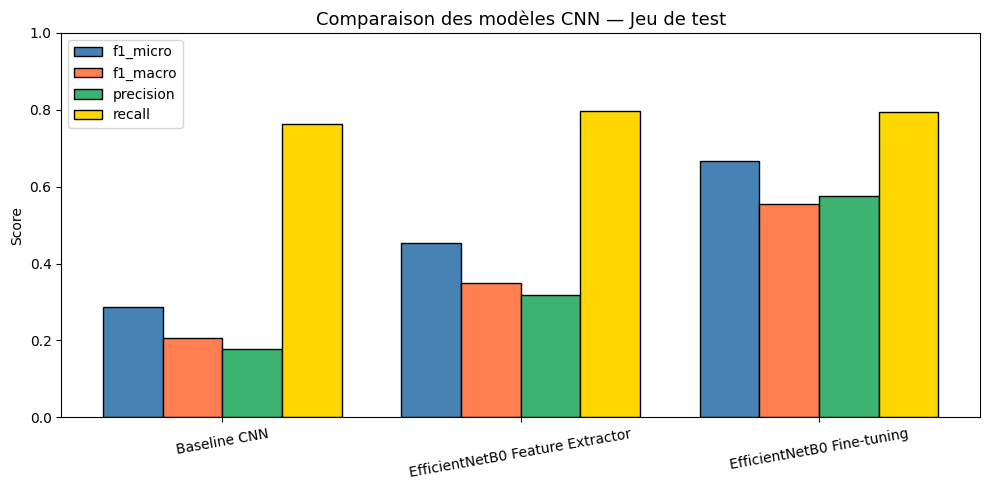


→ Modèle retenu : EfficientNetB0 Fine-tuning (F1 micro le plus élevé)
  Justification : le transfer learning bénéficie des features ImageNet,
  le fine-tuning adapte les couches profondes à notre domaine spécifique.


In [13]:
# ── Visualisation comparative ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
width = 0.2
metrics_names = ['f1_micro', 'f1_macro', 'precision', 'recall']
colors = ['steelblue', 'coral', 'mediumseagreen', 'gold']

for i, (metric, color) in enumerate(zip(metrics_names, colors)):
    ax.bar(x + i * width, comparison[metric], width, label=metric, color=color, edgecolor='black')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison['Modèle'], rotation=10)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Comparaison des modèles CNN — Jeu de test', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('../monitoring/output/img_model_comparison.png', bbox_inches='tight')
plt.show()

# Le meilleur modèle
best_model_name = comparison.loc[comparison['f1_micro'].idxmax(), 'Modèle']
print(f"\n→ Modèle retenu : {best_model_name} (F1 micro le plus élevé)")
print("  Justification : le transfer learning bénéficie des features ImageNet,")
print("  le fine-tuning adapte les couches profondes à notre domaine spécifique.")

In [14]:
# ── Sauvegarder le modèle final ───────────────────────────────────────────────
# On retient EfficientNetB0 Fine-tuned comme modèle image final
BEST_MODEL_IMG = efficientnet_ft
torch.save(BEST_MODEL_IMG.state_dict(), '../model/image_model_final.pth')

# Sauvegarder le MLB pour cohérence avec les autres notebooks
with open('../data/multimodal/mlb.pkl', 'wb') as f:
    pickle.dump(mlb, f)
print("✓ Modèle image final sauvegardé : model/image_model_final.pth")

✓ Modèle image final sauvegardé : model/image_model_final.pth


## 8. Analyse du modèle final

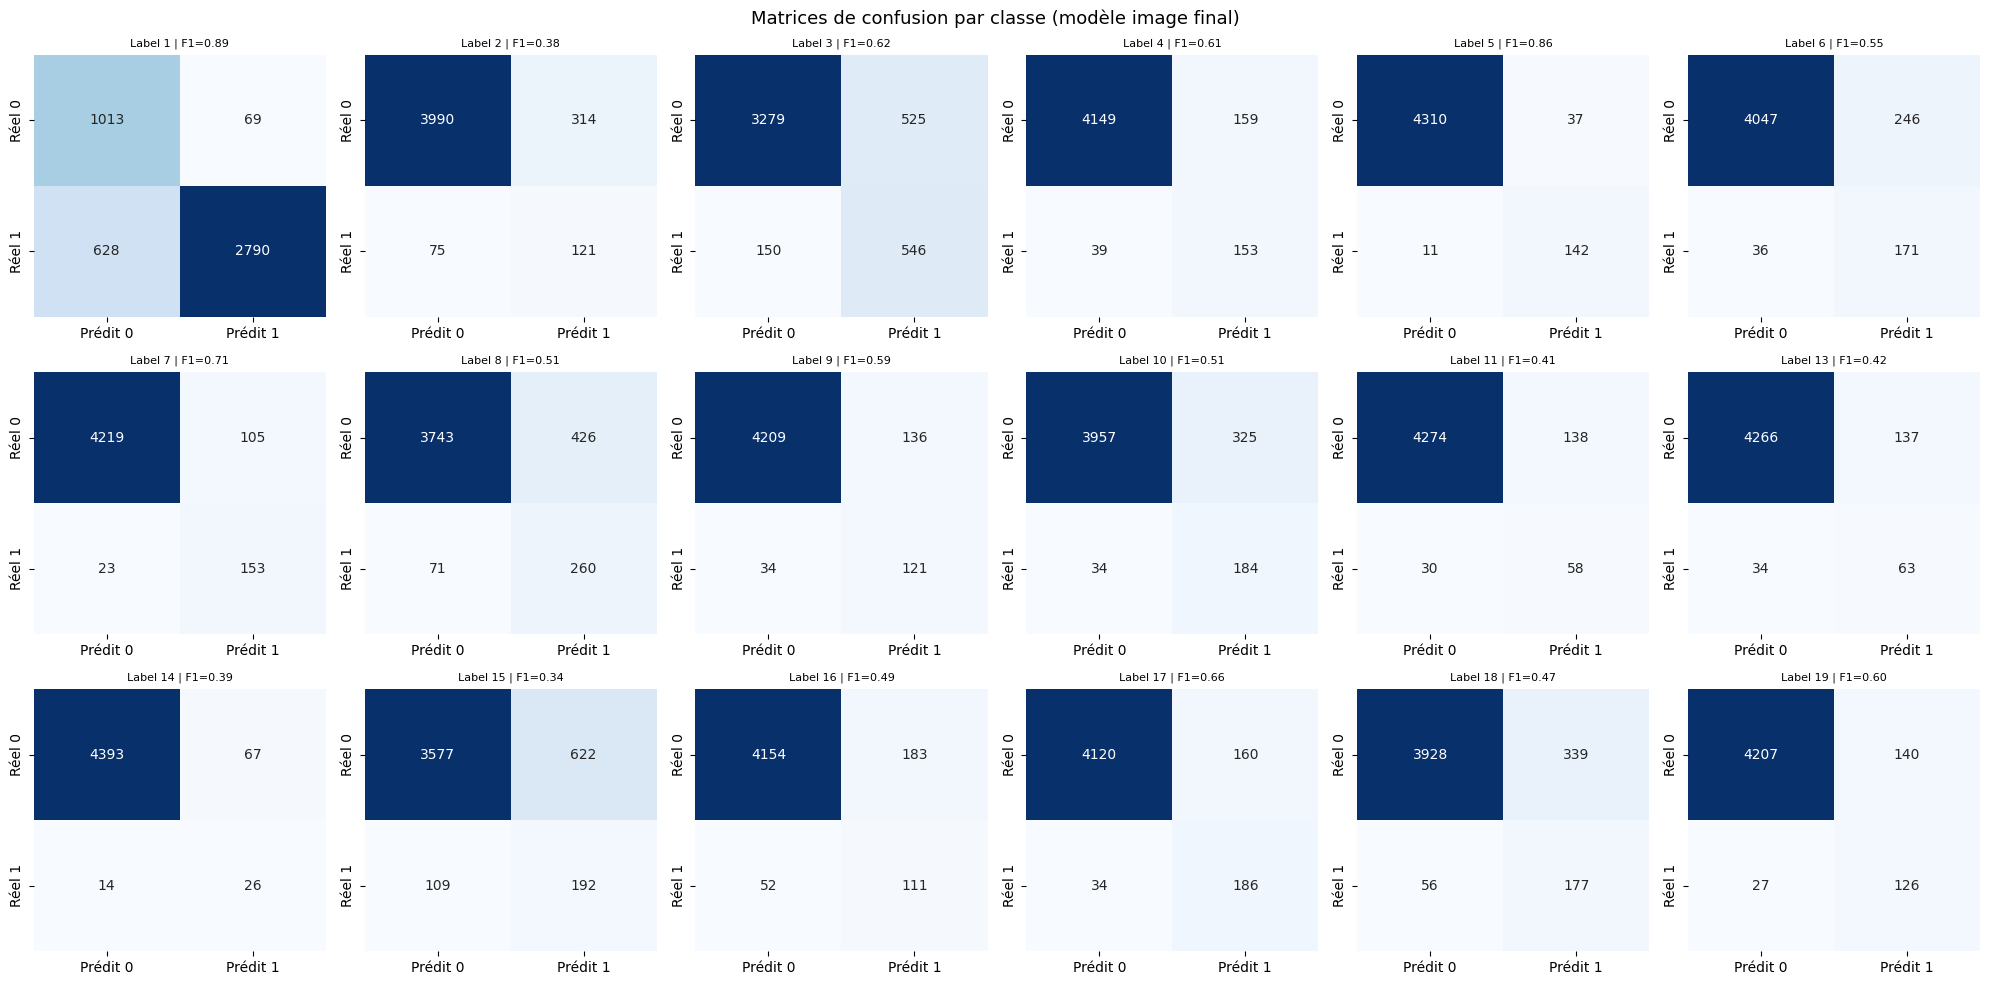

In [15]:
# ── 8.1 Matrices de confusion par classe ─────────────────────────────────────
y_true_final, y_pred_final, y_proba_final = evaluate_model(BEST_MODEL_IMG, test_loader, DEVICE)

mcm = multilabel_confusion_matrix(y_true_final, y_pred_final)

fig, axes = plt.subplots(3, 6, figsize=(20, 10))
for i, (ax, label) in enumerate(zip(axes.flatten(), ALL_LABELS)):
    sns.heatmap(
        mcm[i], annot=True, fmt='d', cmap='Blues',
        xticklabels=['Prédit 0', 'Prédit 1'],
        yticklabels=['Réel 0',   'Réel 1'],
        ax=ax, cbar=False
    )
    f1_c = f1_score(y_true_final[:, i], y_pred_final[:, i], zero_division=0)
    ax.set_title(f'Label {label} | F1={f1_c:.2f}', fontsize=8)
plt.suptitle('Matrices de confusion par classe (modèle image final)', fontsize=13)
plt.tight_layout()
plt.savefig('../monitoring/output/img_confusion_matrices.png', bbox_inches='tight')
plt.show()

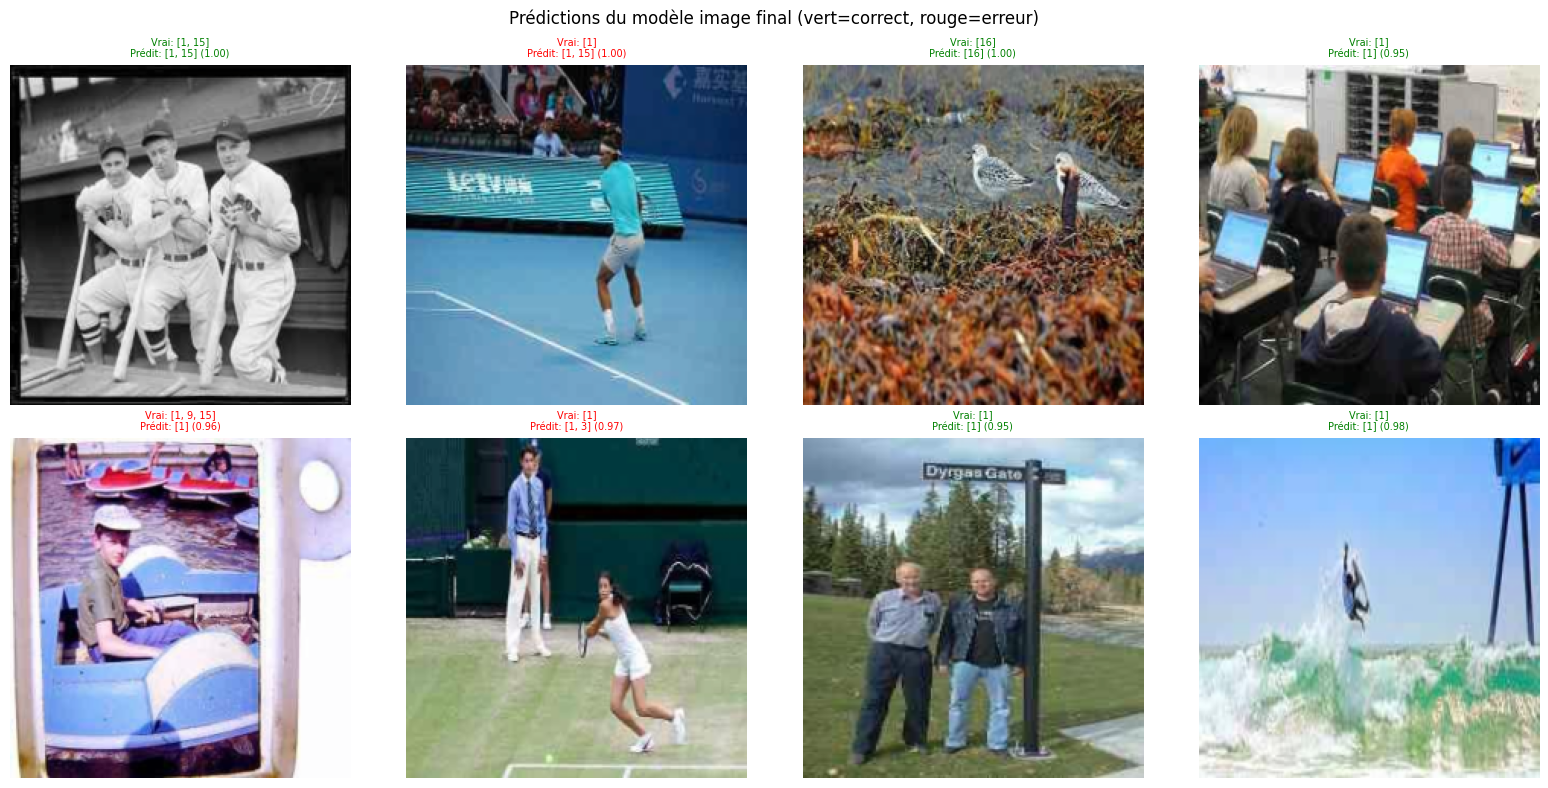

In [16]:
# ── 8.2 Exemples de prédictions avec scores de confiance ─────────────────────
BEST_MODEL_IMG.eval()
sample_images, sample_labels = next(iter(test_loader))
with torch.no_grad():
    logits = BEST_MODEL_IMG(sample_images.to(DEVICE))
    probs  = torch.sigmoid(logits).cpu().numpy()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()[:8]):
    img_np = sample_images[i].permute(1, 2, 0).numpy()
    # Dé-normalisation pour affichage
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img_np = (img_np * std + mean).clip(0, 1)

    true_labels = [ALL_LABELS[j] for j in range(N_CLASSES) if sample_labels[i, j] == 1]
    pred_labels = [ALL_LABELS[j] for j in range(N_CLASSES) if probs[i, j] >= THRESHOLD]
    max_prob    = probs[i].max()

    ax.imshow(img_np)
    ax.set_title(
        f"Vrai: {true_labels}\nPrédit: {pred_labels} ({max_prob:.2f})",
        fontsize=7, color='green' if true_labels == pred_labels else 'red'
    )
    ax.axis('off')

plt.suptitle('Prédictions du modèle image final (vert=correct, rouge=erreur)', fontsize=12)
plt.tight_layout()
plt.savefig('../monitoring/output/img_predictions_examples.png', bbox_inches='tight')
plt.show()

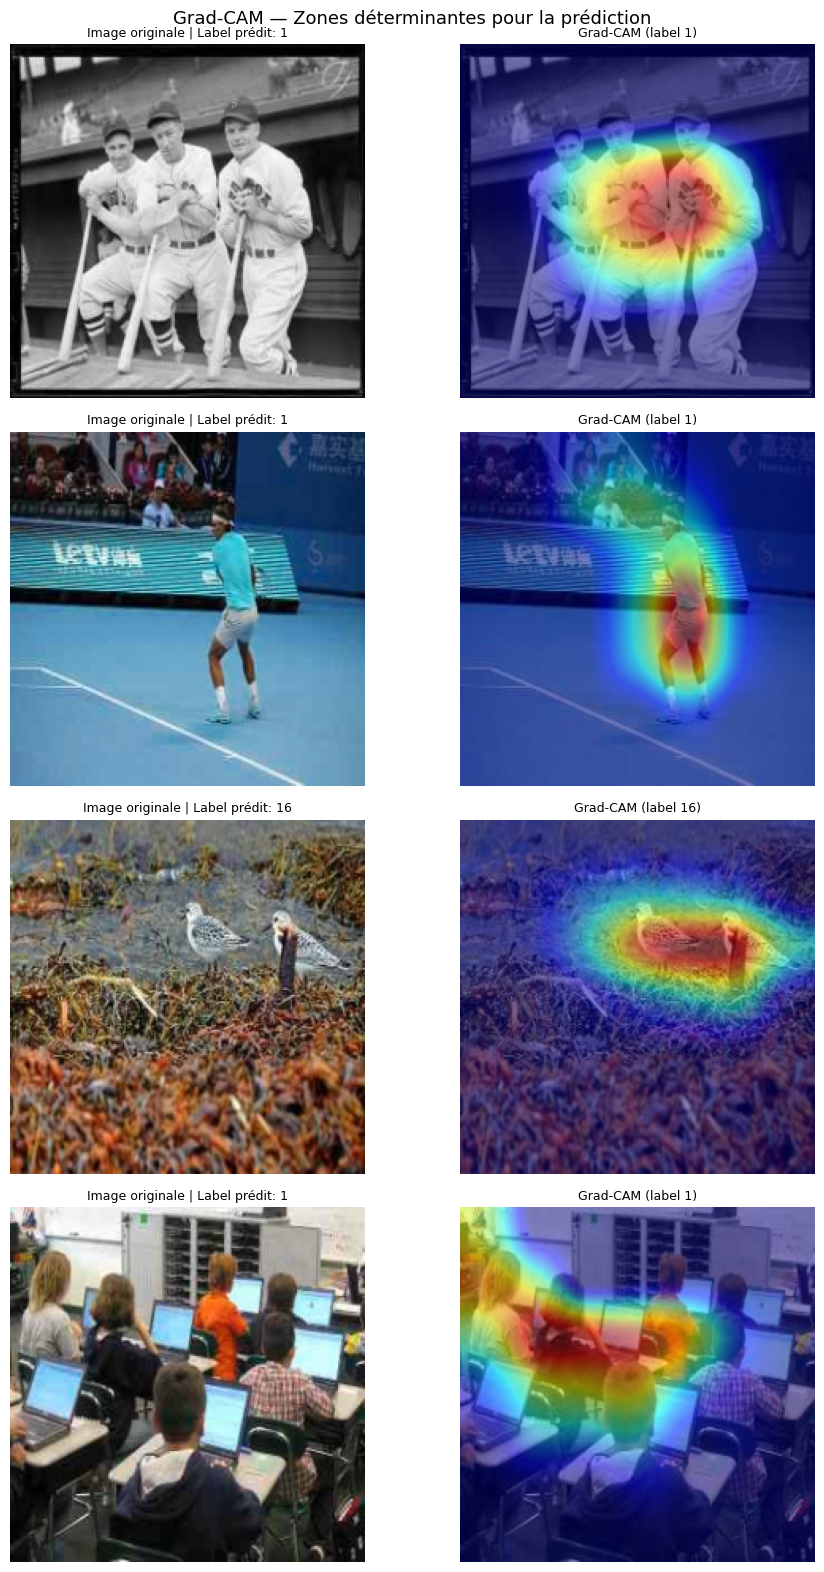

In [17]:
# ── 8.3 XAI — Grad-CAM (visualisation des zones d'attention) ─────────────────
# Grad-CAM : les gradients de la dernière couche conv permettent de visualiser
# les régions de l'image que le modèle "regarde" pour sa décision.

from torch.nn import functional as F

def get_gradcam(model, image_tensor, class_idx, target_layer):
    """Calcule la carte d'activation Grad-CAM pour la classe donnée."""
    gradients = []
    activations = []

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    def forward_hook(module, inp, out):
        activations.append(out)

    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_backward_hook(backward_hook)

    model.eval()
    output = model(image_tensor.unsqueeze(0).to(DEVICE))
    model.zero_grad()
    output[0, class_idx].backward()

    h1.remove()
    h2.remove()

    # Pondération des canaux par leurs gradients
    grads  = gradients[0].squeeze(0)       # (C, H, W)
    acts   = activations[0].squeeze(0)     # (C, H, W)
    weights = grads.mean(dim=(1, 2))       # (C,)
    cam    = (weights[:, None, None] * acts).sum(dim=0)  # (H, W)
    cam    = F.relu(cam)
    cam    = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam.detach().cpu().numpy()


# Couche cible : dernier bloc features d'EfficientNet
target_layer = list(efficientnet_ft.features.children())[-1]

# Afficher Grad-CAM pour 4 images
fig, axes = plt.subplots(4, 2, figsize=(10, 16))
for row_idx in range(4):
    img_tensor = sample_images[row_idx]
    probs_i    = probs[row_idx]
    top_class  = probs_i.argmax()  # classe la plus probable

    cam = get_gradcam(efficientnet_ft, img_tensor, top_class, target_layer)
    cam_resized = np.array(Image.fromarray((cam * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE)))

    # Image originale
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = (img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])).clip(0, 1)

    axes[row_idx, 0].imshow(img_np)
    axes[row_idx, 0].set_title(f'Image originale | Label prédit: {ALL_LABELS[top_class]}', fontsize=9)
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(img_np)
    axes[row_idx, 1].imshow(cam_resized, cmap='jet', alpha=0.5)
    axes[row_idx, 1].set_title(f'Grad-CAM (label {ALL_LABELS[top_class]})', fontsize=9)
    axes[row_idx, 1].axis('off')

plt.suptitle('Grad-CAM — Zones déterminantes pour la prédiction', fontsize=13)
plt.tight_layout()
plt.savefig('../monitoring/output/img_gradcam.png', bbox_inches='tight')
plt.show()

In [18]:
# ── 8.4 Analyse des erreurs ───────────────────────────────────────────────────
# Identifier les classes avec le F1 le plus bas
f1_per_class = f1_score(y_true_final, y_pred_final, average=None, zero_division=0)

error_df = pd.DataFrame({'label': ALL_LABELS, 'f1': f1_per_class}).sort_values('f1')
print("Classes avec les F1 les plus faibles :")
print(error_df.head(5).to_string(index=False))

print("\n→ Les classes rares (faible fréquence dans l'EDA) ont tendance à avoir")
print("  un F1 faible : le modèle prédit peu ces labels car ils sont sous-représentés.")
print("  Solutions possibles : augmentation ciblée, oversampling, pos_weight plus fort.")

Classes avec les F1 les plus faibles :
 label       f1
    15 0.344395
     2 0.383518
    14 0.390977
    11 0.408451
    13 0.424242

→ Les classes rares (faible fréquence dans l'EDA) ont tendance à avoir
  un F1 faible : le modèle prédit peu ces labels car ils sont sous-représentés.
  Solutions possibles : augmentation ciblée, oversampling, pos_weight plus fort.


## Synthèse

| Modèle | F1 micro | F1 macro | Précision | Rappel | Observations |
|--------|----------|----------|-----------|--------|--------------|
| Baseline CNN | 0.2873 | 0.2072 | 0.1770 | 0.7621 | Sous-ajustement, features CNN simples |
| EfficientNetB0 FE | 0.4544 | 0.3484 | 0.3177 | 0.7974 | Amélioration grâce aux features ImageNet |
| **EfficientNetB0 FT** | **0.6665** | **0.5553** | **0.5748** | **0.7930** | **Meilleur : adaptation au domaine** |

**Modèle retenu** : EfficientNetB0 Fine-tuned ()

**Justification** : le fine-tuning partiel (3,18M paramètres entraînés sur 4,03M) permet d'adapter les représentations profondes au domaine tout en conservant les features basses/moyennes d'ImageNet. La BCELoss pondérée () atténue l'impact du déséquilibre des classes. Gain de **+37.9 pts de F1 micro** par rapport à la baseline CNN.

**Classes les plus difficiles** (F1 < 0.45) :

| Label | F1 FT |
|-------|-------|
| 15 | 0.344 |
| 2  | 0.384 |
| 14 | 0.391 |
| 11 | 0.408 |
| 13 | 0.424 |

Ces labels correspondent aux classes rares identifiées dans l'EDA — le modèle prédit peu ces labels car ils sont sous-représentés.

**Limites et pistes d'amélioration** :
- Optimiser le seuil de décision par classe via courbe ROC/PR (au lieu de threshold=0.5 global)
- Essayer EfficientNetB3 ou ResNet50 pour plus de capacité
- Augmentation ciblée sur les classes rares (oversampling, mixup)
- Label smoothing pour réduire la sur-confiance sur les classes fréquentes